In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import os

In [3]:
import os

for f in os.listdir("/content/drive/MyDrive/"):
    if "AI-NN" in f:
        base_path = f"/content/drive/MyDrive/{f}/"
        print("Detected path:", base_path)

Detected path: /content/drive/MyDrive/AI-NN files /


Loading data

In [4]:
file_path = base_path + "processed_data.csv"

df = pd.read_csv(file_path, nrows=300000)

print("Loaded:", df.shape)

Loaded: (300000, 134)


Cleaning

In [5]:
# Remove non-numeric columns
non_numeric_cols = df.select_dtypes(include=['object']).columns
print("Dropping non-numeric columns:", list(non_numeric_cols))

df = df.drop(columns=non_numeric_cols)

# Optional: also drop datetime if detected
df = df.select_dtypes(include=[np.number])

# Fill missing values
df = df.fillna(0)

print("After cleaning:", df.shape)

Dropping non-numeric columns: ['timestamp', 'Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7']
After cleaning: (300000, 121)


Defining target

In [6]:
target_column = 'length_of_study_time_step'  # TTE target

# If not found, fallback
if target_column not in df.columns:
    target_column = df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300000, 120)
y shape: (300000,)


Train/Test

In [7]:
n = len(X)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (210000, 120)
Val: (45000, 120)
Test: (45000, 120)


Scaling

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

MLP       Building Neural Network

In [13]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # regression output
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

DNN

In [14]:
model_dnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

model_dnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_dnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,497 (103.50 KB)

 Trainable params: 26,497 (103.50 KB)

 Non-trainable params: 0 (0.00 B)

MLP Training

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # use separate validation set
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 18052.1582 - mae: 98.8722 - val_loss: 4352.6152 - val_mae: 48.3661
Epoch 2/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6115.1670 - mae: 61.5959 - val_loss: 4493.2222 - val_mae: 47.0132
Epoch 3/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5769.0581 - mae: 58.8755 - val_loss: 4243.9077 - val_mae: 45.9490
Epoch 4/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5524.1870 - mae: 57.0073 - val_loss: 4332.2056 - val_mae: 47.9932
Epoch 5/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5309.2417 - mae: 55.3166 - val_loss: 5869.0962 - val_mae: 53.2332
Epoch 6/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5120.4102 - mae: 53.7650 - val_loss: 4426.9585 - val_mae: 48.7812
Epoch 7/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 4954.1089 - mae: 52.5130 - val_loss: 4964.8374 - val_mae: 49.1440
Epoch 8/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4815.3989 - mae: 51.4324 - val_loss: 5719.1660 - val_mae:

DNN Training

In [16]:
history_dnn = model_dnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 16782.4551 - mae: 94.2620 - val_loss: 4863.5591 - val_mae: 50.4907
Epoch 2/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 6003.2812 - mae: 60.6733 - val_loss: 4973.4038 - val_mae: 49.1477
Epoch 3/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 5638.7725 - mae: 57.8434 - val_loss: 4694.4053 - val_mae: 48.7170
Epoch 4/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5382.9648 - mae: 55.7884 - val_loss: 4888.2891 - val_mae: 50.8644
Epoch 5/30
821/821 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5150.5708 - mae: 54.0525 - val_loss: 4845.3184 - val_mae: 50.8777


Evaluation

In [17]:
# MLP
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MLP MAE:", mae)
print("MLP RMSE:", rmse)


# DNN
preds_dnn = model_dnn.predict(X_test)
mae_dnn = mean_absolute_error(y_test, preds_dnn)
rmse_dnn = np.sqrt(mean_squared_error(y_test, preds_dnn))

print("DNN MAE:", mae_dnn)
print("DNN RMSE:", rmse_dnn)

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MLP MAE: 54.39306618428548
MLP RMSE: 74.60626655418005
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
DNN MAE: 63.10123057420519
DNN RMSE: 83.60545353676727


Plot

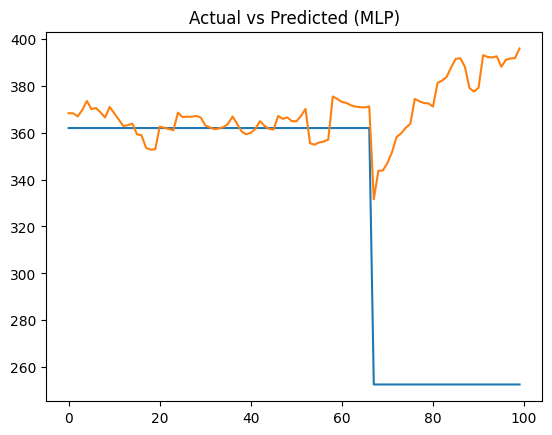

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test[:100].values)
plt.plot(preds[:100])
plt.title("Actual vs Predicted (MLP)")
plt.show()

In [19]:
print("Comparison:")
print("MLP RMSE:", rmse)
print("DNN RMSE:", rmse_dnn)

Comparison:
MLP RMSE: 74.60626655418005
DNN RMSE: 83.60545353676727


Saving the model

In [20]:
model.save(base_path + "nn_model.h5")
print("Model saved!")

Model saved!


In [21]:
from tensorflow.keras.models import load_model

model = load_model(base_path + "nn_model.h5", compile=False)

print("Model loaded successfully!")

Model loaded successfully!
